In [45]:
import gc
import json
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import transformers
import datasets
import trl
import peft

from datasets import Dataset, load_dataset
from peft import LoraConfig, AutoPeftModelForCausalLM
from transformers import AutoTokenizer, BitsAndBytesConfig, set_seed
from trl import DPOConfig, DPOTrainer

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("TRL:", trl.__version__)
print("PEFT:", peft.__version__)

PyTorch: 2.10.0a0+b558c986e8.nv25.11
Transformers: 4.56.2
Datasets: 4.3.0
TRL: 0.22.2
PEFT: 0.20.0


In [46]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
OUTPUT_DIR = "outputs/qwen2_5_0_5b_dpo_lora"

# Dataset options:
#   "inline"        -> uses the four examples included below
#   "json"          -> loads a local JSON file containing prompt/chosen/rejected
#   "ultrafeedback" -> loads a subset of trl-lib/ultrafeedback_binarized
DATA_SOURCE = "inline"

JSON_PATH = "preference_data.json"
ULTRAFEEDBACK_MAX_SAMPLES = 2_000

# 4-bit QLoRA is enabled automatically on a CUDA GPU.
USE_4BIT_IF_CUDA = True

MAX_LENGTH = 512
TRAIN_BATCH_SIZE = 1
EVAL_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8
LEARNING_RATE = 5e-5
BETA = 0.1
INLINE_MAX_STEPS = 40

print("Model:", MODEL_NAME)
print("Dataset source:", DATA_SOURCE)
print("Output directory:", OUTPUT_DIR)

Model: Qwen/Qwen2.5-0.5B-Instruct
Dataset source: inline
Output directory: outputs/qwen2_5_0_5b_dpo_lora


In [47]:
HAS_CUDA = torch.cuda.is_available()
SUPPORTS_BF16 = HAS_CUDA and torch.cuda.is_bf16_supported()

USE_BF16 = SUPPORTS_BF16
USE_FP16 = HAS_CUDA and not SUPPORTS_BF16
USE_4BIT = HAS_CUDA and USE_4BIT_IF_CUDA

if USE_BF16:
    COMPUTE_DTYPE = torch.bfloat16
elif USE_FP16:
    COMPUTE_DTYPE = torch.float16
else:
    COMPUTE_DTYPE = torch.float32

if HAS_CUDA:
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: not available; CPU training will be slow.")

print("BF16:", USE_BF16)
print("FP16:", USE_FP16)
print("4-bit QLoRA:", USE_4BIT)
print("Compute dtype:", COMPUTE_DTYPE)
     

GPU: NVIDIA GB10
BF16: True
FP16: False
4-bit QLoRA: True
Compute dtype: torch.bfloat16


In [48]:
INLINE_DATA = [
    {
        "prompt": "Explain what machine learning is in simple words.",
        "chosen": "Machine learning is a way to teach computers to learn patterns from data and make predictions or decisions without being explicitly programmed for every case.",
        "rejected": "Machine learning is a machine that automatically learns everything without data.",
    },
    {
        "prompt": "What is overfitting in machine learning?",
        "chosen": "Overfitting happens when a model memorizes the training data too closely and performs poorly on new unseen data.",
        "rejected": "Overfitting means the model becomes perfect for all types of data.",
    },
    {
        "prompt": "What is the difference between classification and regression?",
        "chosen": "Classification predicts categories or labels, while regression predicts continuous numerical values.",
        "rejected": "Classification and regression are exactly the same thing.",
    },
    {
        "prompt": "What is the purpose of a loss function?",
        "chosen": "A loss function measures how far a model's predictions are from the true values, guiding the model during training.",
        "rejected": "A loss function increases model size and does not affect training.",
    },
]


def convert_plain_text_to_conversational(example):
    """Convert plain prompt/chosen/rejected strings into chat messages."""
    if isinstance(example.get("prompt"), str):
        return {
            "prompt": [{"role": "user", "content": example["prompt"]}],
            "chosen": [{"role": "assistant", "content": example["chosen"]}],
            "rejected": [{"role": "assistant", "content": example["rejected"]}],
        }
    return example


if DATA_SOURCE == "inline":
    dataset = Dataset.from_list(INLINE_DATA)
    dataset = dataset.map(convert_plain_text_to_conversational)

elif DATA_SOURCE == "json":
    json_path = Path(JSON_PATH)
    if not json_path.exists():
        raise FileNotFoundError(
            f"{JSON_PATH!r} was not found. Upload the file or change JSON_PATH."
        )

    dataset = load_dataset("json", data_files=str(json_path), split="train")
    required_columns = {"prompt", "chosen", "rejected"}
    missing = required_columns - set(dataset.column_names)
    if missing:
        raise ValueError(f"The JSON file is missing columns: {sorted(missing)}")

    dataset = dataset.map(convert_plain_text_to_conversational)

elif DATA_SOURCE == "ultrafeedback":
    dataset = load_dataset(
        "trl-lib/ultrafeedback_binarized",
        split="train",
    )
    dataset = dataset.shuffle(seed=SEED)
    sample_count = min(ULTRAFEEDBACK_MAX_SAMPLES, len(dataset))
    dataset = dataset.select(range(sample_count))

else:
    raise ValueError(
        "DATA_SOURCE must be 'inline', 'json', or 'ultrafeedback'."
    )

print(dataset)
print("\nColumns:", dataset.column_names)
print("\nFirst example:")
print(json.dumps(dataset[0], indent=2, ensure_ascii=False))
     

Map: 100%|██████████| 4/4 [00:00<00:00, 2038.05 examples/s]

Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 4
})

Columns: ['prompt', 'chosen', 'rejected']

First example:
{
  "prompt": [
    {
      "content": "Explain what machine learning is in simple words.",
      "role": "user"
    }
  ],
  "chosen": [
    {
      "content": "Machine learning is a way to teach computers to learn patterns from data and make predictions or decisions without being explicitly programmed for every case.",
      "role": "assistant"
    }
  ],
  "rejected": [
    {
      "content": "Machine learning is a machine that automatically learns everything without data.",
      "role": "assistant"
    }
  ]
}


In [49]:
required_columns = {"chosen", "rejected"}
missing_columns = required_columns - set(dataset.column_names)

if missing_columns:
    raise ValueError(
        f"DPO requires chosen and rejected columns. Missing: {missing_columns}"
    )

if len(dataset) < 2:
    raise ValueError("At least two preference examples are required.")

test_size = 1 if len(dataset) < 20 else 0.05

split_dataset = dataset.train_test_split(
    test_size=test_size,
    seed=SEED,
)

train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print("Training examples:", len(train_dataset))
print("Evaluation examples:", len(eval_dataset))

Training examples: 3
Evaluation examples: 1


In [50]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "left"

print("Pad token:", tokenizer.pad_token)
print("EOS token:", tokenizer.eos_token)
print("Padding side:", tokenizer.padding_side)

Pad token: <|endoftext|>
EOS token: <|im_end|>
Padding side: left


In [51]:
quantization_config = None

if USE_4BIT:
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=COMPUTE_DTYPE,
        bnb_4bit_use_double_quant=True,
    )

print("Quantization configuration:")
print(quantization_config)

Quantization configuration:
BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "bfloat16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}



In [52]:
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules="all-linear",
)

print(peft_config)

LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.20.0', base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules='all-linear', exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)


In [54]:
model_init_kwargs = {
    "dtype": COMPUTE_DTYPE,
    "trust_remote_code": True,
    "attn_implementation": "sdpa",
}

is_tiny_inline_demo = DATA_SOURCE == "inline"

training_args = DPOConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=1.0,
    max_steps=INLINE_MAX_STEPS if is_tiny_inline_demo else -1,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    optim="paged_adamw_8bit" if USE_4BIT else "adamw_torch",
    max_grad_norm=1.0,
    beta=BETA,
    loss_type="sigmoid",
    max_length=MAX_LENGTH,
    truncation_mode="keep_start",
    bf16=USE_BF16,
    fp16=USE_FP16,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    eval_strategy="steps",
    eval_steps=10,
    logging_steps=1,
    logging_first_step=True,
    save_strategy="steps",
    save_steps=20,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
    data_seed=SEED,
    model_init_kwargs=model_init_kwargs,
)

print(training_args)

UnslothDPOConfig(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
base_model_attribute_name=model,
batch_eval_metrics=False,
beta=0.1,
bf16=True,
bf16_full_eval=False,
data_seed=42,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
dataset_num_proc=8,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_dropout=True,
disable_tqdm=False,
discopop_tau=0.05,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=2,
eval_delay=0,
eval_do_concat_batches=True,
eval_on

In [56]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_LENGTH,
    dtype=COMPUTE_DTYPE,
    load_in_4bit=USE_4BIT,
)

==((====))==  Unsloth 2026.8.7: Fast Qwen2 patching. Transformers: 4.56.2.
   \\   /|    NVIDIA GB10. Num GPUs = 1. Max memory: 121.69 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0a0+b558c986e8.nv25.11. CUDA: 12.1. CUDA Toolkit: 13.0. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33+aa7bc36.d20260807. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


In [58]:
trainer = DPOTrainer(
    model=model,
    ref_model=None,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    peft_config=peft_config,
    quantization_config=quantization_config,
)

trainer.model.print_trainable_parameters()

[trl.trainer.dpo_trainer|WARNING][RANK 0] You passed model_init_kwargs to the `DPOConfig`, but your model is already instantiated. The `model_init_kwargs` will be ignored.
[unsloth.import_fixes|WARNING]Unsloth: Ignoring an unusable torchao so LoRA can still be built (Found an incompatible version of torchao. Found version 0.14.0+git, but only versions above 0.16.0 are supported). Run `pip install --upgrade torchao` if you need torchao quantization.
num_proc must be <= 3. Reducing num_proc to 3 for dataset of size 3.
[datasets.arrow_dataset|WARNING]num_proc must be <= 3. Reducing num_proc to 3 for dataset of size 3.
Extracting prompt in train dataset (num_proc=3): 100%|██████████| 3/3 [00:00<00:00,  5.73 examples/s]
num_proc must be <= 3. Reducing num_proc to 3 for dataset of size 3.
[datasets.arrow_dataset|WARNING]num_proc must be <= 3. Reducing num_proc to 3 for dataset of size 3.
Applying chat template to train dataset (num_proc=3): 100%|██████████| 3/3 [00:01<00:00,  2.72 examples/s

trainable params: 8,798,208 || all params: 502,830,976 || trainable%: 1.7497


In [59]:
initial_metrics = trainer.evaluate()
print("Initial evaluation metrics:")
for key, value in initial_metrics.items():
    print(f"{key}: {value}")

Initial evaluation metrics:
eval_loss: 0.6931471824645996
eval_model_preparation_time: 0.0029
eval_runtime: 0.6349
eval_samples_per_second: 1.575
eval_steps_per_second: 1.575
eval_rewards/chosen: 0.0
eval_rewards/rejected: 0.0
eval_rewards/accuracies: 0.0
eval_rewards/margins: 0.0
eval_logps/chosen: -75.68528747558594
eval_logps/rejected: -82.62980651855469
eval_logits/chosen: -2.310058355331421
eval_logits/rejected: -0.5223329663276672


In [61]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
)

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
Unsloth 2026.8.7 patched 24 layers with 24 QKV layers, 24 O layers and 24 MLP layers.


In [62]:
train_result = trainer.train()

print("Training completed.")
print("Global steps:", trainer.state.global_step)
print("Training loss:", train_result.training_loss)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 3 | Num Epochs = 40 | Total steps = 40
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 8,798,208 of 502,830,976 (1.75% trained)


Step,Training Loss,Validation Loss,Model Preparation Time,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/chosen,Logps/rejected,Logits/chosen,Logits/rejected
10,0.693100,0.693147,0.002900,0.000000,0.000000,0.000000,0.000000,-75.685287,-82.629807,-2.310058,-0.522333
20,0.693100,0.693147,0.002900,0.000000,0.000000,0.000000,0.000000,-75.685287,-82.629807,-2.310058,-0.522333
30,0.693100,0.693147,0.002900,0.000000,0.000000,0.000000,0.000000,-75.685287,-82.629807,-2.310058,-0.522333
40,0.693100,0.693147,0.002900,0.000000,0.000000,0.000000,0.000000,-75.685287,-82.629807,-2.310058,-0.522333


Training completed.
Global steps: 40
Training loss: 0.6931471824645996


,loss,grad_norm,learning_rate,rewards/chosen,rewards/rejected,rewards/accuracies,rewards/margins,logps/chosen,logps/rejected,logits/chosen,...,eval_rewards/margins,eval_logps/chosen,eval_logps/rejected,eval_logits/chosen,eval_logits/rejected,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
25,0.6931,9.522223,2.282111e-05,0.0,0.0,0.0,0.0,-72.936371,-73.157051,-2.30172,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,0.6931,9.522223,2.065880e-05,0.0,0.0,0.0,0.0,-72.936378,-73.157059,-2.30172,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,0.6931,9.522223,1.852952e-05,0.0,0.0,0.0,0.0,-72.936371,-73.157051,-2.30172,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,0.6931,9.522223,1.644950e-05,0.0,0.0,0.0,0.0,-72.936378,-73.157059,-2.30172,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,0.6931,9.522223,1.443454e-05,0.0,0.0,0.0,0.0,-72.936378,-73.157059,-2.30172,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,0.6931,9.522223,1.250000e-05,0.0,0.0,0.0,0.0,-72.936378,-73.157059,-2.30172,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31,0.6931,9.522223,1.066059e-05,0.0,0.0,0.0,0.0,-72.936371,-73.157051,-2.30172,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,-75.685287,-82.629807,-2.310058,-0.522333,NaN,NaN,NaN,NaN,NaN
33,0.6931,9.522223,8.930310e-06,0.0,0.0,0.0,0.0,-72.936371,-73.157051,-2.30172,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,0.6931,9.522223,7.322330e-06,0.0,0.0,0.0,0.0,-72.936378,-73.157059,-2.30172,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


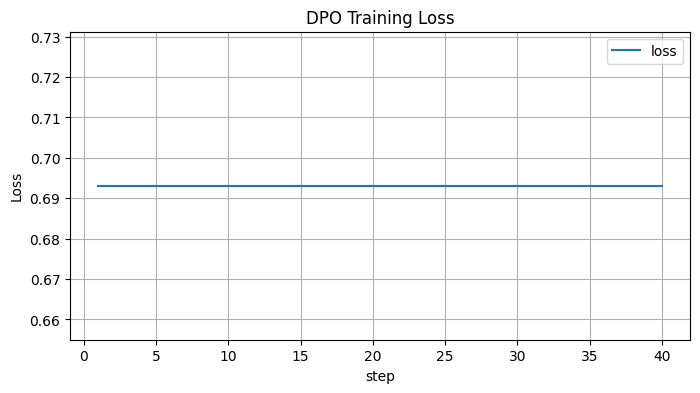

In [63]:
history = pd.DataFrame(trainer.state.log_history)
display(history.tail(20))

loss_history = history.dropna(subset=["loss"]) if "loss" in history.columns else pd.DataFrame()
if not loss_history.empty:
    ax = loss_history.plot(
        x="step",
        y="loss",
        title="DPO Training Loss",
        grid=True,
        figsize=(8, 4),
    )
    ax.set_ylabel("Loss")

In [64]:
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print(f"Saved DPO LoRA adapter and tokenizer to: {OUTPUT_DIR}")
print("Saved files:")
for file_name in sorted(os.listdir(OUTPUT_DIR)):
    print(" -", file_name)

Saved DPO LoRA adapter and tokenizer to: outputs/qwen2_5_0_5b_dpo_lora
Saved files:
 - README.md
 - adapter_config.json
 - adapter_model.safetensors
 - added_tokens.json
 - chat_template.jinja
 - checkpoint-20
 - checkpoint-40
 - merges.txt
 - special_tokens_map.json
 - tokenizer.json
 - tokenizer_config.json
 - training_args.bin
 - vocab.json


In [65]:
del trainer
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Training objects released.")

Training objects released.


In [66]:
inference_load_kwargs = {
    "torch_dtype": COMPUTE_DTYPE,
}

if HAS_CUDA:
    inference_load_kwargs["device_map"] = "auto"

if quantization_config is not None:
    inference_load_kwargs["quantization_config"] = quantization_config

model = AutoPeftModelForCausalLM.from_pretrained(
    OUTPUT_DIR,
    **inference_load_kwargs,
)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(
    OUTPUT_DIR,
    trust_remote_code=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "left"

print("DPO adapter loaded successfully.")

DPO adapter loaded successfully.


In [73]:
merged_model.save_pretrained("outputs/dpo_merged")
tokenizer.save_pretrained("outputs/dpo_merged")

('outputs/dpo_merged/tokenizer_config.json',
 'outputs/dpo_merged/special_tokens_map.json',
 'outputs/dpo_merged/chat_template.jinja',
 'outputs/dpo_merged/vocab.json',
 'outputs/dpo_merged/merges.txt',
 'outputs/dpo_merged/added_tokens.json',
 'outputs/dpo_merged/tokenizer.json')

In [74]:
from transformers import AutoModelForCausalLM, AutoTokenizer

clean_model = AutoModelForCausalLM.from_pretrained(
    "outputs/dpo_merged",
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
clean_tokenizer = AutoTokenizer.from_pretrained("outputs/dpo_merged")

In [76]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

clean_model = AutoModelForCausalLM.from_pretrained(
    "outputs/dpo_merged",
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
clean_tokenizer = AutoTokenizer.from_pretrained("outputs/dpo_merged")

def generate_response(prompt, max_new_tokens=150, temperature=0.7, top_p=0.9):
    messages = [{"role": "user", "content": prompt}]
    formatted_prompt = clean_tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True,
    )
    inputs = clean_tokenizer(formatted_prompt, return_tensors="pt").to(clean_model.device)
    prompt_token_count = inputs["input_ids"].shape[1]

    gen_kwargs = {
        "max_new_tokens": max_new_tokens,
        "pad_token_id": clean_tokenizer.pad_token_id,
        "eos_token_id": clean_tokenizer.eos_token_id,
    }
    if temperature > 0:
        gen_kwargs.update({"do_sample": True, "temperature": temperature, "top_p": top_p})
    else:
        gen_kwargs["do_sample"] = False

    with torch.inference_mode():
        outputs = clean_model.generate(**inputs, **gen_kwargs)

    new_tokens = outputs[0, prompt_token_count:]
    return clean_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

prompt = "Explain overfitting in machine learning in simple words."
response = generate_response(prompt)
print("Prompt:", prompt)
print("\nDPO response:", response)

AttributeError: 'Qwen2Attention' object has no attribute 'apply_qkv'